# Python Week-2
## Colab
### Anaconda
#### Jupyter
Colab

In [1]:
# 指定課程名稱給變數 course_name
course_name = "Python與資料科學"

# 使用 print() 輸出歡迎訊息
print('"歡迎"來到', course_name)


"歡迎"來到 Python與資料科學


In [2]:
# 建立四個不同型態的變數
student_count = 60                    # 整數
average_sleep_hours = 6.7             # 浮點數
course_name = "Python與資料科學"       # 字串
has_missing_value = True              # 布林值

# 使用 type() 檢查每個變數的型態
print("student_count 型態：", type(student_count))
print("average_sleep_hours 型態：", type(average_sleep_hours))
print("course_name 型態：", type(course_name))
print("has_missing_value 型態：", type(has_missing_value))


student_count 型態： <class 'int'>
average_sleep_hours 型態： <class 'float'>
course_name 型態： <class 'str'>
has_missing_value 型態： <class 'bool'>


In [ ]:
a=10
b=11
print(a+b)

21


In [ ]:
strAAA='hello world!!!'
print(strAAA)

hello world!!!


Python : 3.13.15
PyTorch: 2.11.0+cpu
TorchVision: 0.26.0+cpu
CUDA 可用: False
⚠️ 未偵測到 GPU，將使用 CPU 執行（訓練會較慢）
Epoch  1/30 | Train Loss: 0.6711 | Val Loss: 0.6416 | Val Acc: 83.25%
Epoch  5/30 | Train Loss: 0.2543 | Val Loss: 0.1828 | Val Acc: 100.00%
Epoch 10/30 | Train Loss: 0.0265 | Val Loss: 0.0239 | Val Acc: 100.00%
Epoch 15/30 | Train Loss: 0.0093 | Val Loss: 0.0096 | Val Acc: 100.00%
Epoch 20/30 | Train Loss: 0.0050 | Val Loss: 0.0057 | Val Acc: 100.00%
Epoch 25/30 | Train Loss: 0.0032 | Val Loss: 0.0039 | Val Acc: 100.00%
Epoch 30/30 | Train Loss: 0.0023 | Val Loss: 0.0029 | Val Acc: 100.00%


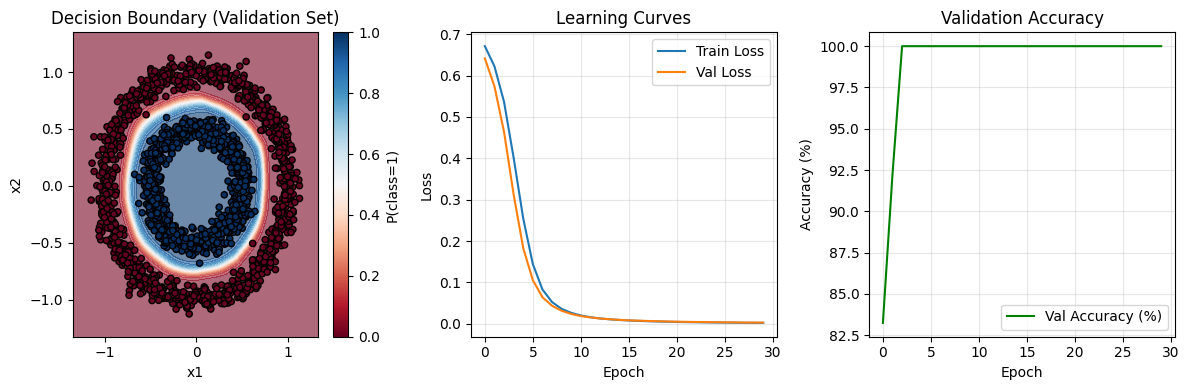


模型參數總數: 4,417 (可訓練: 4,417)


In [ ]:
# ------------------------------------------------------------
#  Google Colab 完整範例：環境檢查 + 資料視覺化 + PyTorch 訓練
#  複製整段到 Colab 儲存格，按 Shift+Enter 即可執行
# ------------------------------------------------------------

# 1. 環境檢查
import torch, torchvision, platform, sys, os, json, subprocess, math, random
print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA 可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 裝置 :", torch.cuda.get_device_name(0))
    print("CUDA 版本:", torch.version.cuda)
    # 顯示 GPU 記憶體
    free, total = torch.cuda.mem_get_info()
    print(f"GPU 記憶體: {free/1e9:.2f} / {total/1e9:.2f} GB 可用")
else:
    print("⚠️ 未偵測到 GPU，將使用 CPU 執行（訓練會較慢）")

# 2. 固定隨機種子，確保可重現
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 3. 產生合成資料（二分類：兩個同心圓）
from sklearn.datasets import make_circles
import numpy as np
import matplotlib.pyplot as plt

X_np, y_np = make_circles(n_samples=2000, noise=0.06, factor=0.5, random_state=SEED)
X = torch.from_numpy(X_np).float()
y = torch.from_numpy(y_np).float().unsqueeze(1)

# 切分訓練/驗證
from torch.utils.data import TensorDataset, DataLoader, random_split
dataset = TensorDataset(X, y)
train_len = int(0.8 * len(dataset))
val_len = len(dataset) - train_len
train_ds, val_ds = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# 4. 定義簡單 MLP
class SimpleMLP(torch.nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMLP(hidden=64).to(device)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 5. 訓練迴圈
EPOCHS = 30
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    # ---- 訓練 ----
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= train_len

    # ---- 驗證 ----
    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == yb).sum().item()
    val_loss /= val_len
    val_acc = correct / val_len

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc*100:.2f}%")

# 6. 視覺化：決策邊界 + 學習曲線
def plot_decision_boundary(model, X, y, device, title="Decision Boundary"):
    model.eval()
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(device)
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)
    plt.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k", s=20)
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.colorbar(label="P(class=1)")

plt.figure(figsize=(12, 4))

# 6-1 決策邊界
plt.subplot(1, 3, 1)
plot_decision_boundary(model, X_np, y_np, device, "Decision Boundary (Validation Set)")

# 6-2 學習曲線
plt.subplot(1, 3, 2)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Learning Curves")
plt.legend(); plt.grid(True, alpha=0.3)

# 6-3 準確率曲線
plt.subplot(1, 3, 3)
plt.plot([a*100 for a in history["val_acc"]], label="Val Accuracy (%)", color="green")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. 顯示最終模型參數量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n模型參數總數: {total_params:,} (可訓練: {trainable_params:,})")
